/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


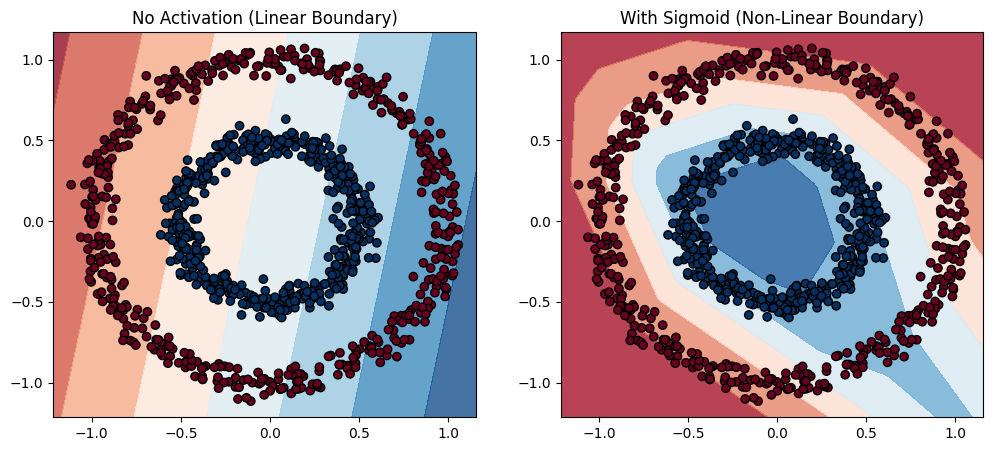

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

# 1. Create a Non-Linear Dataset - Circles
# This data cannot be separated by a straight line.
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

def plot_decision_boundary(model, X, y, title):
    # Setup grid for plotting
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Predict over the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.title(title)

# 2. MODEL 1: No Activation Function (Purely Linear)
model_linear = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation=None, input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid') # Final output only
])
model_linear.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_linear.fit(X, y, epochs=50, verbose=0)

# 3. MODEL 2: With Sigmoid Activation
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_sigmoid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_sigmoid.fit(X, y, epochs=50, verbose=0)

# 4. Plotting the Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_linear, X, y, "No Activation (Linear Boundary)")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_sigmoid, X, y, "With Sigmoid (Non-Linear Boundary)")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 1. Prepare dummy data (e.g., predicting if a student passes based on 2 scores)
# Input: [Study Hours, Sleep Hours]
X = np.array([[2, 5], [3, 8], [8, 8], [7, 5], [1, 2], [9, 9]], dtype=float)
# Output: [Pass (1) or Fail (0)]
y = np.array([0, 0, 1, 1, 0, 1], dtype=float)

# 2. Build the Model
model = Sequential([
    # Input Layer + Hidden Layer 1: 4 neurons, ReLU activation
    Dense(units=4, activation='relu', input_shape=(2,)),

    # Hidden Layer 2: 4 neurons, ReLU activation
    Dense(units=4, activation='relu'),

    # Output Layer: 1 neuron, Sigmoid (for probability between 0 and 1)
    Dense(units=1, activation='sigmoid')
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
print("Starting training...")
model.fit(X, y, epochs=100, verbose=0)

# 5. Make a Prediction
test_student = np.array([[8, 6]]) # High study, medium sleep
prediction = model.predict(test_student)
print(f"\nPrediction for test student: {prediction[0][0]:.2f}")
print("Result:", "Pass" if prediction > 0.5 else "Fail")

Starting training...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.3950
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5000 - loss: 0.3946
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.3937
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.3930
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.3923
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.3916
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.3910
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.3903
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.3896
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.3889
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.3883
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - ac

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8672 - loss: 0.4557 - val_accuracy: 0.9685 - val_loss: 0.1122
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9664 - loss: 0.1098 - val_accuracy: 0.9705 - val_loss: 0.1011
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9776 - loss: 0.0709 - val_accuracy: 0.9757 - val_loss: 0.0834
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9841 - loss: 0.0516 - val_accuracy: 0.9722 - val_loss: 0.0947
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9863 - loss: 0.0424 - val_accuracy: 0.9778 - val_loss: 0.0856
313/313 - 1s - 2ms/step - accuracy: 0.9734 - loss: 0.0967

Test accuracy: 0.9733999967575073


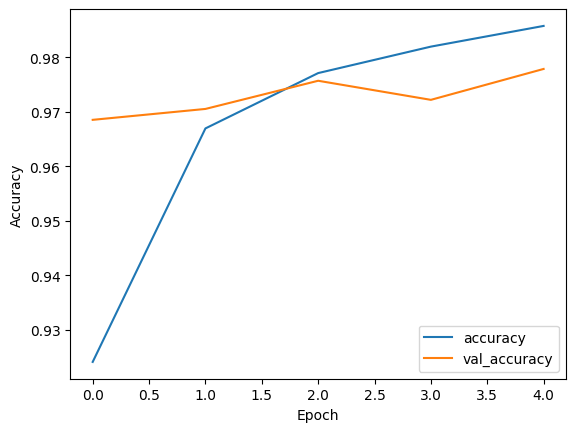

In [ ]:
import tensorflow as tf

from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

# Load dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocessing: Normalize pixel values to be between 0 and 1

x_train, x_test = x_train / 255.0, x_test / 255.0

# #

# 2. Building the ANN Model

# For image classification with a standard ANN, we must first "flatten" the 28x28 images into a 1D vector of 784 pixels.


model = models.Sequential([

    layers.Flatten(input_shape=(28, 28)), # Input Layer

    layers.Dense(128, activation='relu'), # Hidden Layer 1

    layers.Dense(64, activation='relu'),  # Hidden Layer 2

    layers.Dense(10, activation='softmax') # Output Layer (10 classes)

])

#

# 3. Compilation & Training

# We use `sparse_categorical_crossentropy` because our labels are integers (0-9).

#

model.compile(optimizer='adam',

              loss='sparse_categorical_crossentropy',

              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

#

# 4. Performance Evaluation

# Teaching students to look beyond just training accuracy is vital.

#

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f'\nTest accuracy: {test_acc}')

# Plotting results

plt.plot(history.history['accuracy'], label='accuracy')

plt.plot(history.history['val_accuracy'], label = 'val_accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(loc='lower right')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


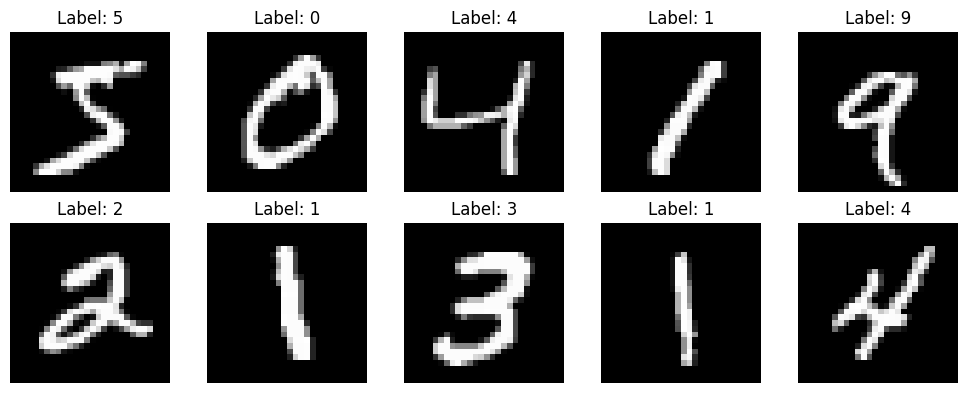

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8657 - loss: 0.4622 - val_accuracy: 0.9667 - val_loss: 0.1156
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9664 - loss: 0.1126 - val_accuracy: 0.9673 - val_loss: 0.1080
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9763 - loss: 0.0751 - val_accuracy: 0.9775 - val_loss: 0.0821
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9828 - loss: 0.0544 - val_accuracy: 0.9778 - val_loss: 0.0767
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9862 - loss: 0.0426 - val_accuracy: 0.9733 - val_loss: 0.0902
313/313 - 0s - 1ms/step - accuracy: 0.9724 - loss: 0.0988
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step


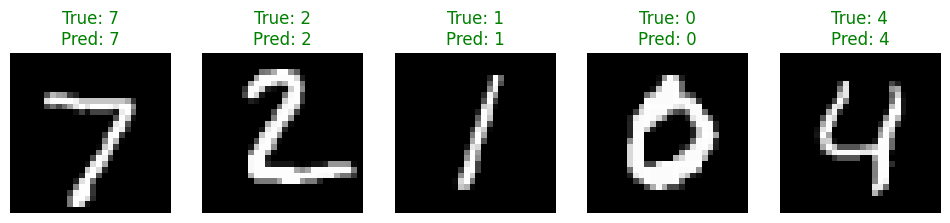

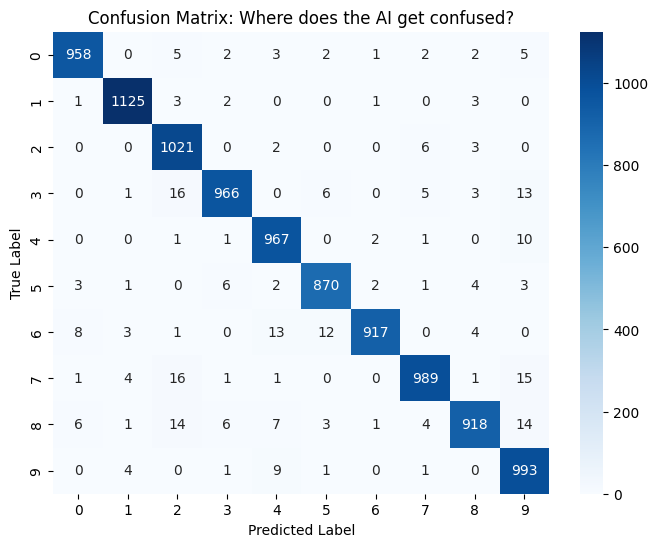

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np # New import for math operations
import seaborn as sns # New import for the Heatmap
from sklearn.metrics import confusion_matrix # New import for Matrix calculation

# --- 1. DATA PREPARATION ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# --- NEW: VISUALIZE DATASET SAMPLES ---
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 2. MODEL BUILDING
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. COMPILATION & TRAINING
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 4. EVALUATION
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

#  NEW: VISUALIZE PREDICTIONS
y_pred_probs = model.predict(x_test) # Softmax probabilities
y_pred = np.argmax(y_pred_probs, axis=1) # Choosing the highest probability index

plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    color = 'green' if y_test[i] == y_pred[i] else 'red'
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}", color=color)
    plt.axis('off')
plt.show()

# --- NEW: CONFUSION MATRIX ---
# This shows which digits the model is getting "confused" between.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where does the AI get confused?')
plt.show()